In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (precision_recall_curve, 
                           average_precision_score,
                           roc_curve, auc)

plt.style.use('ggplot')
sns.set_palette("viridis")

# DATA LOADING 
print("Loading data...")
train = pd.read_csv('C:/Users/zarin/Downloads/train_80.csv')
test = pd.read_csv('C:/Users/zarin/Downloads/test_20.csv')

# Convert booleans 
for df in [train, test]:
    df['school_charter_t'] = df['school_charter_t'].astype(str).str.upper() == 'TRUE'
    df['school_magnet_t'] = df['school_magnet_t'].astype(str).str.upper() == 'TRUE'



Loading data...


In [6]:
# FEATURE ENGINEERING
def safe_feature_engineering(df):
    df = df.copy()
    df['students_reached'] = df['students_reached'].replace(0, 1)
    df['price_per_student'] = df['total_price_excluding_optional_support'] / df['students_reached']
    
    # Add month cyclical encoding
    df['posted_month_sin'] = np.sin(2 * np.pi * df['posted_month']/12)
    df['posted_month_cos'] = np.cos(2 * np.pi * df['posted_month']/12)
    
    return df

train = safe_feature_engineering(train)
test = safe_feature_engineering(test)



In [7]:
#CATEGORICAL HANDLING 
print("Processing categorical features...")

categorical_cols = [
    'primary_focus_subject', 'primary_focus_area',
    'school_metro', 'grade_level', 'resource_type',
    'poverty_level', 'school_charter_t', 'school_magnet_t'
]

numeric_features = ['price_per_student', 'students_reached', 
                   'posted_month_sin', 'posted_month_cos']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])



Processing categorical features...


In [9]:
#  MODEL PIPELINE 
model = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        class_weight={0: 2.5, 1: 1},
        max_depth=25,
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
)

# Prepare data
X_train = train.drop('label', axis=1)
y_train = train['label']
X_test = test.drop('label', axis=1)
y_test = test['label']



In [10]:
#  TRAINING & PREDICTION 
print("Training model...")
model.fit(X_train, y_train)

test['prob_unfunded'] = model.predict_proba(X_test)[:, 0]  # P(unfunded)



Training model...


C:\Users\zarin\AppData\Local\Temp\ipykernel_39728\477754347.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='poverty_level', y='prob_unfunded', data=test,


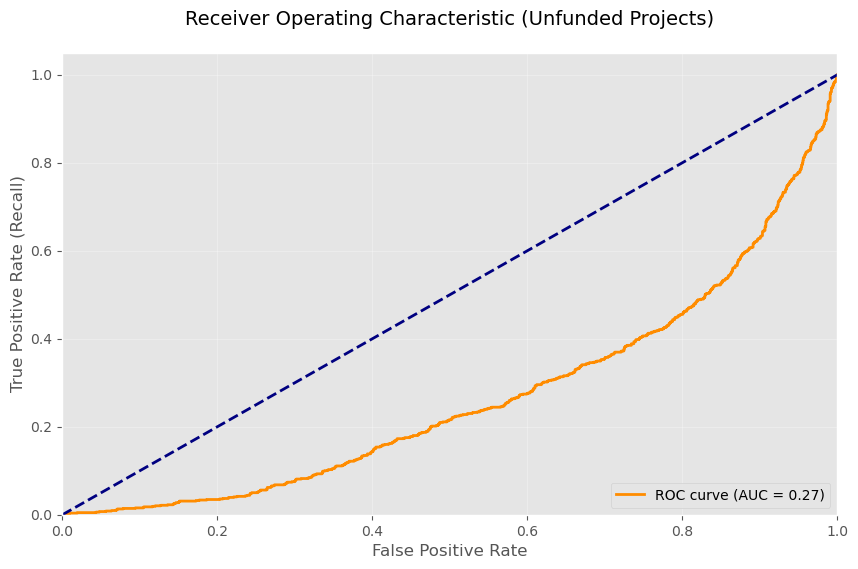

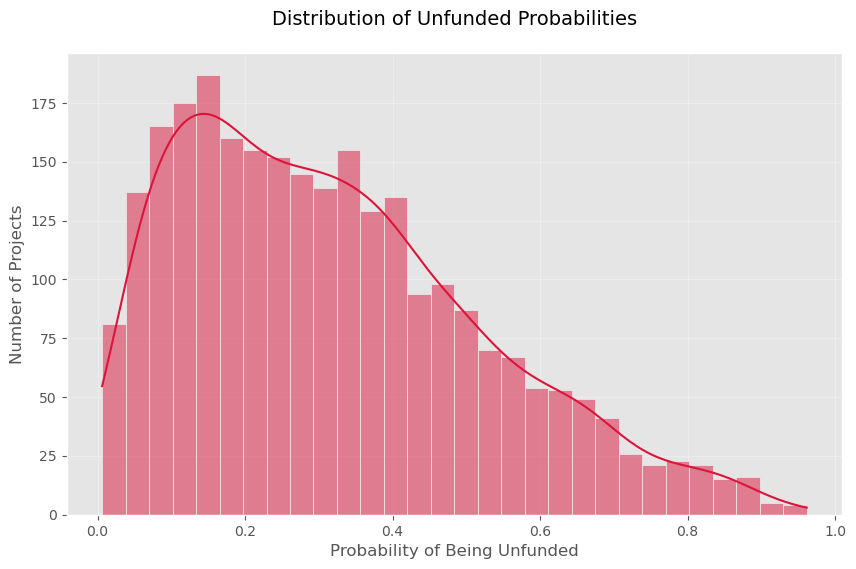

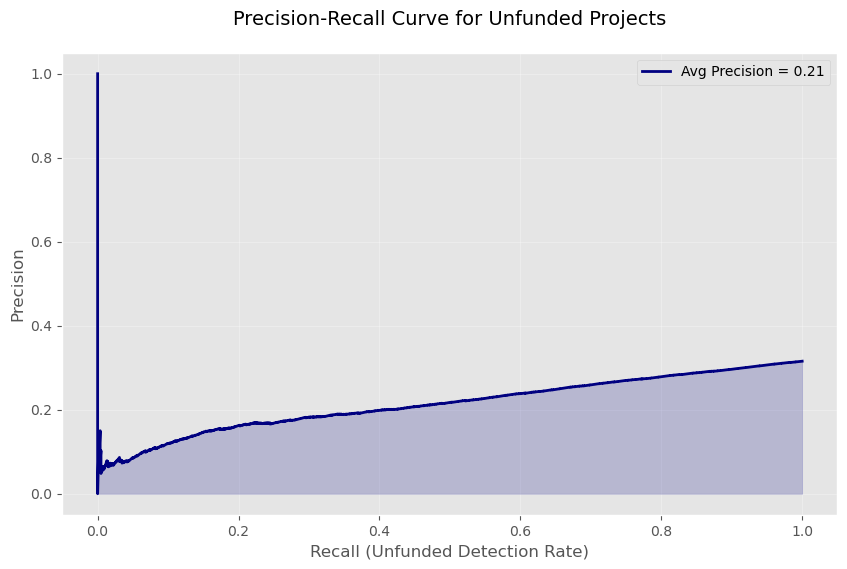

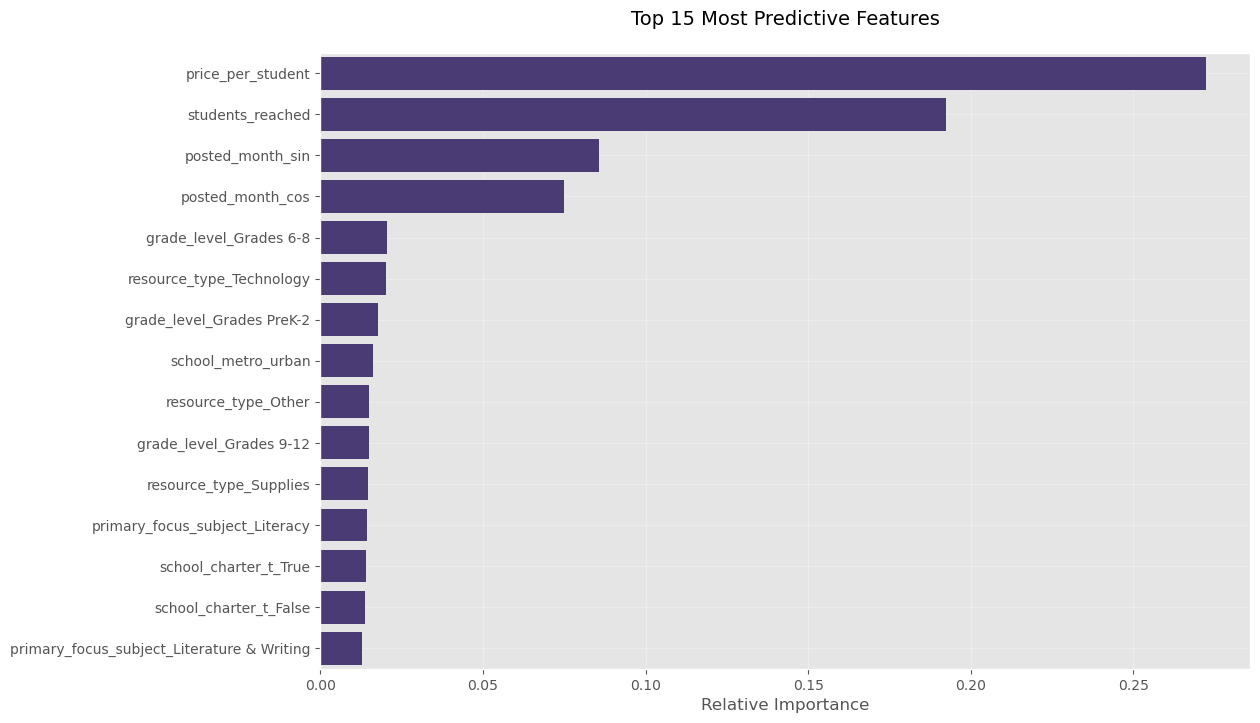

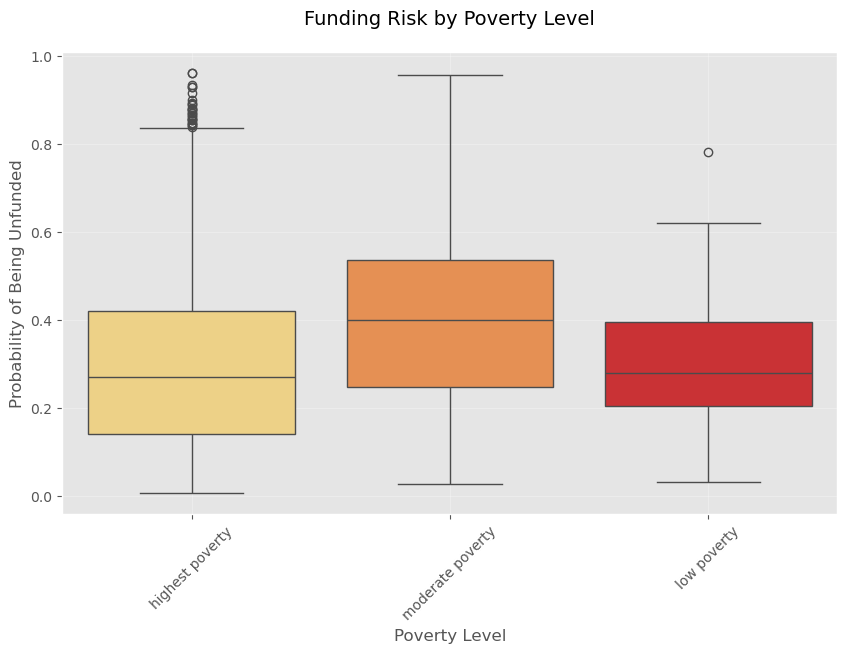

In [11]:
# VISUALIZATIONS 

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, 1-test['prob_unfunded'], pos_label=0)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (Unfunded Projects)', fontsize=14, pad=20)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('C:/Users/zarin/Downloads/roc_curve.png', 
            bbox_inches='tight', dpi=300)

# 2. Probability Distribution
plt.figure(figsize=(10, 6))
sns.histplot(test['prob_unfunded'], bins=30, kde=True, color='crimson')
plt.title('Distribution of Unfunded Probabilities', fontsize=14, pad=20)
plt.xlabel('Probability of Being Unfunded', fontsize=12)
plt.ylabel('Number of Projects', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('C:/Users/zarin/Downloads/probability_distribution.png', 
            bbox_inches='tight', dpi=300)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, 1-test['prob_unfunded'], pos_label=0)
avg_precision = average_precision_score(y_test, 1-test['prob_unfunded'], pos_label=0)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='navy', lw=2,
         label=f'Avg Precision = {avg_precision:.2f}')
plt.fill_between(recall, precision, alpha=0.2, color='navy')
plt.xlabel('Recall (Unfunded Detection Rate)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve for Unfunded Projects', fontsize=14, pad=20)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.savefig('C:/Users/zarin/Downloads/precision_recall_curve.png', 
            bbox_inches='tight', dpi=300)

# 4. Feature Importance (Top 15)
feature_importances = model.named_steps['randomforestclassifier'].feature_importances_
cat_encoder = model.named_steps['columntransformer'].named_transformers_['cat']
all_categories = cat_encoder.get_feature_names_out(categorical_cols)
all_features = numeric_features + list(all_categories)

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top 15 Most Predictive Features', fontsize=14, pad=20)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('')
plt.grid(True, alpha=0.3)
plt.savefig('C:/Users/zarin/Downloads/feature_importance.png', 
            bbox_inches='tight', dpi=300)

# 5. Poverty Level vs Funding Probability
plt.figure(figsize=(10, 6))
sns.boxplot(x='poverty_level', y='prob_unfunded', data=test,
            order=['highest poverty', 'moderate poverty', 'low poverty'],
            palette='YlOrRd')
plt.title('Funding Risk by Poverty Level', fontsize=14, pad=20)
plt.xlabel('Poverty Level', fontsize=12)
plt.ylabel('Probability of Being Unfunded', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.savefig('C:/Users/zarin/Downloads/poverty_impact.png', 
            bbox_inches='tight', dpi=300)


In [12]:

# UTPUT GENERATION 
print("Creating output files...")

# Priority Tiers
test['tier'] = pd.cut(test['prob_unfunded'],
                     bins=[0, 0.6, 0.75, 0.9, 1],
                     labels=['Tier 4: Low Risk', 'Tier 3: Medium Risk', 
                            'Tier 2: High Risk', 'Tier 1: Critical Risk'])

# Save results to CSV
output_cols = [
    'tier', 'prob_unfunded', 'poverty_level',
    'price_per_student', 'students_reached',
    'resource_type', 'primary_focus_area'
]

output_file = 'C:/Users/zarin/Downloads/prioritized_projects.csv'
test[output_cols].sort_values('prob_unfunded', ascending=False)\
    .to_csv(output_file, index=False)

print(f"""
=== PIPELINE COMPLETED SUCCESSFULLY ===


Key Insights:
- Model AUC: {roc_auc:.3f} (1.0 is perfect)
- Projects with poverty_level = 'highest poverty' have {test[test['poverty_level']=='highest poverty']['prob_unfunded'].mean():.1%} average unfunded risk
- Top predictive feature: '{importance_df.iloc[0]['Feature']}'
""")

Creating output files...

=== PIPELINE COMPLETED SUCCESSFULLY ===


Key Insights:
- Model AUC: 0.267 (1.0 is perfect)
- Projects with poverty_level = 'highest poverty' have 30.2% average unfunded risk
- Top predictive feature: 'price_per_student'

